In [1]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt


# def crop_interferogram(img, threshold=30):
#     """
#     Crop away black background.
#     """
#     _, mask = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)

#     ys, xs = np.where(mask > 0)

#     ymin, ymax = ys.min(), ys.max()
#     xmin, xmax = xs.min(), xs.max()

#     return img[ymin:ymax, xmin:xmax]


# def estimate_fringe_angle_hough(gray):

#     # Smooth
#     blur = cv2.GaussianBlur(gray, (5, 5), 0)

#     # Low-threshold Canny
#     edges = cv2.Canny(
#         blur,
#         threshold1=10,
#         threshold2=40
#     )

#     # Hough transform
#     lines = cv2.HoughLinesP(
#         edges,
#         rho=1,
#         theta=np.pi / 180,
#         threshold=20,
#         minLineLength=50,
#         maxLineGap=30
#     )

#     if lines is None:
#         return 0.0

#     angles = []
#     weights = []

#     for line in lines:

#         x1, y1, x2, y2 = line[0]

#         angle = np.degrees(
#             np.arctan2(y2 - y1, x2 - x1)
#         )

#         # Map to [-90,90]
#         if angle > 90:
#             angle -= 180

#         if angle < -90:
#             angle += 180

#         # Ignore obvious outliers
#         if abs(angle) > 20:
#             continue

#         length = np.hypot(
#             x2 - x1,
#             y2 - y1
#         )

#         angles.append(angle)
#         weights.append(length)

#     if len(angles) == 0:
#         return 0.0

#     return np.average(
#         angles,
#         weights=weights
#     )


# def rotate_image(gray, angle_deg):

#     h, w = gray.shape

#     center = (w // 2, h // 2)

#     M = cv2.getRotationMatrix2D(
#         center,
#         angle_deg,
#         1.0
#     )

#     cos = abs(M[0, 0])
#     sin = abs(M[0, 1])

#     new_w = int(h * sin + w * cos)
#     new_h = int(h * cos + w * sin)

#     M[0, 2] += (new_w / 2) - center[0]
#     M[1, 2] += (new_h / 2) - center[1]

#     rotated = cv2.warpAffine(
#         gray,
#         M,
#         (new_w, new_h),
#         flags=cv2.INTER_LINEAR
#     )

#     return rotated


# # ===========================
# # MAIN
# # ===========================

# img = cv2.imread(
#     "s0hene_5.tiff",
#     cv2.IMREAD_GRAYSCALE
# )

# crop = crop_interferogram(img)

# hough_angle = estimate_fringe_angle_hough(crop)

# print(f"Hough angle = {hough_angle:.3f} deg")

# # Make fringes vertical
# rotation_angle = 90 + hough_angle

# rotated = rotate_image(
#     crop,
#     rotation_angle
# )

# print(
#     f"Applied rotation = {rotation_angle:.3f} deg"
# )

# # Display
# plt.figure(figsize=(14,6))

# plt.subplot(1,2,1)
# plt.imshow(crop, cmap='gray')
# plt.title("Original Cropped")
# plt.axis('off')

# plt.subplot(1,2,2)
# plt.imshow(rotated, cmap='gray')
# plt.title("Vertical Fringes")
# plt.axis('off')

# plt.tight_layout()
# plt.show()

Applied rotation = 47.34°


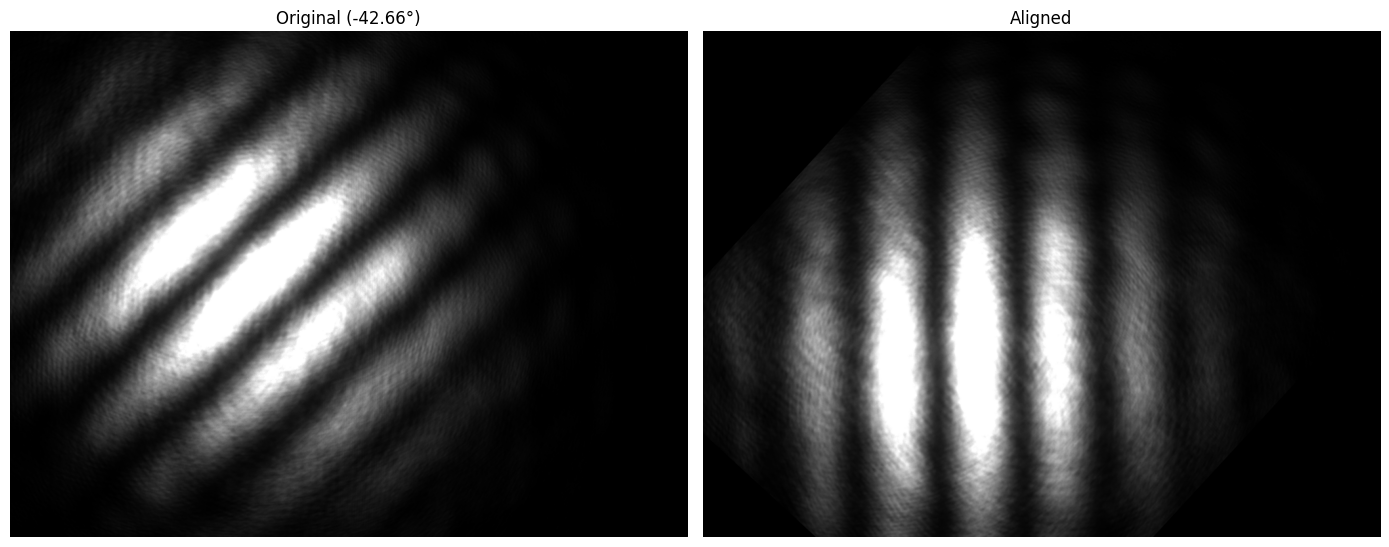

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def crop_interferogram(img, threshold=30):
    """Crop away black background."""
    _, mask = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return img

    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    return img[ymin:ymax + 1, xmin:xmax + 1]


def estimate_fringe_angle_hough(gray):

    # Smooth
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Edge detection
    edges = cv2.Canny(
        blur,
        threshold1=20,
        threshold2=60
    )

    # Probabilistic Hough
    # lines = cv2.HoughLinesP(
    #     edges,
    #     rho=1,
    #     theta=np.pi / 180,
    #     threshold=25,
    #     minLineLength=40,
    #     maxLineGap=20
    # )
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=30,
        minLineLength=min(gray.shape)//6,
        maxLineGap=15
    )
    if lines is None:
        return 0.0

    angles = []
    weights = []

    for line in lines:

        x1, y1, x2, y2 = line[0]

        angle = np.degrees(
            np.arctan2(y2 - y1, x2 - x1)
        )

        # Map to [-90,90)
        angle = ((angle + 90) % 180) - 90

        length = np.hypot(
            x2 - x1,
            y2 - y1
        )

        angles.append(np.deg2rad(angle))
        weights.append(length)

    angles = np.array(angles)
    weights = np.array(weights)

    # Circular mean (180° periodicity)
    sin2 = np.sum(weights * np.sin(2 * angles))
    cos2 = np.sum(weights * np.cos(2 * angles))

    mean_angle = 0.5 * np.arctan2(sin2, cos2)

    return np.degrees(mean_angle)


# def rotate_image(gray, angle_deg):

#     h, w = gray.shape

#     center = (w // 2, h // 2)

#     M = cv2.getRotationMatrix2D(
#         center,
#         angle_deg,
#         1.0
#     )

#     cos = abs(M[0, 0])
#     sin = abs(M[0, 1])

#     new_w = int(h * sin + w * cos)
#     new_h = int(h * cos + w * sin)

#     M[0, 2] += new_w / 2 - center[0]
#     M[1, 2] += new_h / 2 - center[1]

#     rotated = cv2.warpAffine(
#         gray,
#         M,
#         (new_w, new_h),
#         flags=cv2.INTER_LINEAR,
#         borderValue=0
#     )

#     return rotated
def rotate_image(gray, angle_deg):
    h, w = gray.shape

    center = (w / 2, h / 2)

    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    rotated = cv2.warpAffine(
        gray,
        M,
        (w, h),                 # Keep original dimensions
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return rotated

# ===========================
# MAIN
# ===========================

img = cv2.imread(
    r"C:\Users\admin\Desktop\sandeep\data_2\s0hene\s0hene_15.tiff",
    cv2.IMREAD_GRAYSCALE
)

crop = crop_interferogram(img)

angle = estimate_fringe_angle_hough(crop)
vertical_angle = ((90 - angle + 90) % 180) - 90

# Rotate so fringes become vertical
rotation = -vertical_angle

rotated = rotate_image(crop, rotation)

print(f"Applied rotation = {rotation:.2f}°")

plt.figure(figsize=(14,6))

plt.subplot(121)
plt.imshow(crop, cmap="gray")
plt.title(f"Original ({angle:.2f}°)")
plt.axis("off")

plt.subplot(122)
plt.imshow(rotated, cmap="gray")
plt.title("Aligned")
plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import os
import glob
import cv2
import pandas as pd
from tqdm import tqdm

# ==========================================================
# Paths
# ==========================================================

ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4"
OUTPUT_ROOT = r"C:\Users\admin\Desktop\sandeep\SyntheticFringes4\images_corrected_hough2"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

extensions = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff")

# ==========================================================
# Process every folder
# ==========================================================

folders = sorted([
    f for f in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, f))
])

for folder in folders:

    input_dir = os.path.join(ROOT, folder)
    output_dir = os.path.join(OUTPUT_ROOT, folder)

    os.makedirs(output_dir, exist_ok=True)

    image_paths = []
    for ext in extensions:
        image_paths.extend(glob.glob(os.path.join(input_dir, ext)))

    image_paths = sorted(image_paths)

    results = []

    print(f"\nProcessing {folder} ({len(image_paths)} images)")

    for path in tqdm(image_paths):

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        # Crop for robust angle estimation
        crop = crop_interferogram(img)

        # Estimate fringe angle
        fringe_angle = estimate_fringe_angle_hough(crop)

        # Angle relative to vertical
        vertical_angle = ((90 - fringe_angle + 90) % 180) - 90

        # Rotation required
        rotation = -vertical_angle

        # Rotate ORIGINAL image
        corrected = rotate_image(img, rotation)

        filename = os.path.basename(path)

        cv2.imwrite(
            os.path.join(output_dir, filename),
            corrected
        )

        results.append({
            "image": filename,
            "fringe_angle_deg": fringe_angle,
            "vertical_error_deg": vertical_angle,
            "rotation_deg": rotation
        })

    pd.DataFrame(results).to_csv(
        os.path.join(output_dir, "angles.csv"),
        index=False
    )

print("\nDone!")


Processing images (1000 images)


100%|██████████| 1000/1000 [00:08<00:00, 123.57it/s]



Processing images_corrected_hough2 (0 images)


0it [00:00, ?it/s]


Done!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd


def crop_interferogram(img, threshold=30):

    _, mask = cv2.threshold(
        img,
        threshold,
        255,
        cv2.THRESH_BINARY
    )

    ys, xs = np.where(mask > 0)

    ymin, ymax = ys.min(), ys.max()
    xmin, xmax = xs.min(), xs.max()

    return img[ymin:ymax, xmin:xmax]

def estimate_fringe_angle_hough(gray):

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    edges = cv2.Canny(
        blur,
        threshold1=10,
        threshold2=40
    )

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=20,
        minLineLength=50,
        maxLineGap=30
    )

    if lines is None:
        return 0.0

    angles = []
    weights = []

    for line in lines:

        x1,y1,x2,y2 = line[0]

        angle = np.degrees(
            np.arctan2(y2-y1, x2-x1)
        )

        if angle > 90:
            angle -= 180

        if angle < -90:
            angle += 180

        # reject weird directions
        if abs(angle) > 20:
            continue

        length = np.hypot(
            x2-x1,
            y2-y1
        )

        angles.append(angle)
        weights.append(length)

    if len(angles) == 0:
        return 0.0

    return np.average(
        angles,
        weights=weights
    )


# -------------------------
# Rotate image
# -------------------------
def rotate_image(gray, angle_deg):

    h, w = gray.shape

    center = (w//2, h//2)

    M = cv2.getRotationMatrix2D(
        center,
        angle_deg,
        1.0
    )

    cos = abs(M[0,0])
    sin = abs(M[0,1])

    new_w = int(h*sin + w*cos)
    new_h = int(h*cos + w*sin)

    M[0,2] += (new_w/2) - center[0]
    M[1,2] += (new_h/2) - center[1]

    rotated = cv2.warpAffine(
        gray,
        M,
        (new_w, new_h),
        flags=cv2.INTER_LINEAR
    )

    return rotated


input_folder ="C:\\Users\\sande\\Desktop\\ubuntu\\data\\s0red_final"
output_folder ="C:\\Users\\sande\\Desktop\\analysis2\\HOUGH"

os.makedirs(output_folder, exist_ok=True)

results = []

# =========================
# PROCESS ALL FILES
# =========================

for fname in sorted(os.listdir(input_folder)):

    if not fname.lower().endswith(
        (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    ):
        continue

    path = os.path.join(
        input_folder,
        fname
    )

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        continue

    crop = crop_interferogram(img)

    hough_angle = estimate_fringe_angle_hough(crop)

    rotation_angle = hough_angle

    corrected = rotate_image(
        crop,
        rotation_angle
    )

    save_path = os.path.join(
        output_folder,
        fname
    )

    cv2.imwrite(
        save_path,
        corrected
    )

    results.append([
        fname,
        hough_angle,
        rotation_angle
    ])

    print(
        f"{fname} | "
        f"Hough={hough_angle:.3f}° | "
        f"Rot={rotation_angle:.3f}°"
    )

# =========================
# SAVE CSV
# =========================

df = pd.DataFrame(
    results,
    columns=[
        "filename",
        "hough_angle_deg",
        "applied_rotation_deg"
    ]
)

csv_path = os.path.join(
    output_folder,
    "hough_angles.csv"
)

df.to_csv(
    csv_path,
    index=False
)

print("\nSaved:")
print(csv_path)

s0redfinal_1.tiff | Hough=0.000° | Rot=0.000°
s0redfinal_10.tiff | Hough=2.523° | Rot=2.523°
s0redfinal_100.tiff | Hough=0.000° | Rot=0.000°
s0redfinal_101.tiff | Hough=17.272° | Rot=17.272°
s0redfinal_102.tiff | Hough=2.561° | Rot=2.561°
s0redfinal_103.tiff | Hough=0.000° | Rot=0.000°
s0redfinal_104.tiff | Hough=-1.951° | Rot=-1.951°
s0redfinal_105.tiff | Hough=0.000° | Rot=0.000°
s0redfinal_106.tiff | Hough=2.824° | Rot=2.824°
s0redfinal_107.tiff | Hough=1.861° | Rot=1.861°
s0redfinal_108.tiff | Hough=-0.078° | Rot=-0.078°
s0redfinal_109.tiff | Hough=1.801° | Rot=1.801°
s0redfinal_11.tiff | Hough=-2.302° | Rot=-2.302°
s0redfinal_110.tiff | Hough=0.321° | Rot=0.321°
s0redfinal_111.tiff | Hough=-3.134° | Rot=-3.134°
s0redfinal_112.tiff | Hough=1.122° | Rot=1.122°
s0redfinal_113.tiff | Hough=-1.147° | Rot=-1.147°
s0redfinal_114.tiff | Hough=0.408° | Rot=0.408°
s0redfinal_115.tiff | Hough=2.994° | Rot=2.994°
s0redfinal_116.tiff | Hough=-1.795° | Rot=-1.795°
s0redfinal_117.tiff | Hough=-1